<a href="https://colab.research.google.com/github/furkanoguz4/AppSolution/blob/master/turkish_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🇹🇷 Türkçe Müşteri Yorumlarında Duygu Analizi
## Makine Öğrenmesi ve Derin Öğrenme Karşılaştırmalı Çalışması

**Referans Makale:** Ashbaugh, L. & Zhang, Y. (2024). *A Comparative Study of Sentiment Analysis on Customer Reviews Using Machine Learning and Deep Learning.* Computers (MDPI), 13(12), 340.

**Fark:** Bu çalışmada aynı metodoloji **Türkçe e-ticaret yorumları** üzerine uygulanmıştır.

---

### Kullanılan Modeller
| Tür | Model |
|-----|-------|
| Makine Öğrenmesi | Logistic Regression |
| Makine Öğrenmesi | Naive Bayes |
| Makine Öğrenmesi | Random Forest |
| Derin Öğrenme | CNN (Convolutional Neural Network) |
| Derin Öğrenme | RNN (Recurrent Neural Network) |

### Sınıflar
- **Pozitif** (4-5 yıldız)
- **Nötr** (3 yıldız)
- **Negatif** (1-2 yıldız)

## 1. Kütüphaneler

In [ ]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import re
import os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Makine Öğrenmesi
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize

# Derin Öğrenme
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D,
    SimpleRNN, Dense, Dropout, LSTM
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Grafik ayarları
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('darkgrid')

# Tekrarlanabilirlik
np.random.seed(42)
tf.random.set_seed(42)

print('✅ Tüm kütüphaneler yüklendi!')
print(f'   TensorFlow: {tf.__version__}')
print(f'   scikit-learn: {__import__("sklearn").__version__}')

✅ Tüm kütüphaneler yüklendi!
   TensorFlow: 2.20.0
   scikit-learn: 1.6.1


## 2. Veri Seti Yükleme

**Veri Seti:** Türkçe E-Ticaret Ürün Yorumları  
**Kaynak:** https://www.kaggle.com/datasets/burhanbilenn/duygu-analizi-icin-urun-yorumlari

> ⚠️ Kaggle'dan indirip bu notebook ile aynı klasöre koyun: `yorumlar.csv`

In [ ]:
# ── Veri setini yükle ──────────────────────────────────────────────
DATASET_PATH = '/yorumlar.csv'

try:
    df = pd.read_csv(DATASET_PATH, encoding='utf-16')
    print(f'✅ Veri seti yüklendi: {df.shape[0]:,} satır, {df.shape[1]} sütun')
    print(f'\nSütunlar: {list(df.columns)}')
    df.head()
except FileNotFoundError:
    print('⚠️  Dosya bulunamadı! Demo veri seti oluşturuluyor...')

    # Demo veri seti (gerçek veri olmadığında çalışmak için)
    demo_data = {
        'yorum': [
            'Ürün çok kaliteliydi harika bir alışveriş deneyimi yaşadım',
            'Kargo çok hızlı geldi ürün beklentilerimi karşıladı teşekkürler',
            'Mükemmel ürün fiyat performans açısından çok iyi',
            'Harika bir ürün herkese tavsiye ederim',
            'Çok memnun kaldım tekrar sipariş vereceğim',
            'İdare eder fiyatı düşünürsek fena değil',
            'Orta kalite ne iyi ne kötü',
            'Beklentilerimi tam olarak karşılamadı ama kullanılır',
            'Fena değil ama daha iyi olabilirdi',
            'Ortalama bir ürün özellikle bir şey yok',
            'Ürün çok kötüydü kesinlikle tavsiye etmiyorum',
            'Kargo geç geldi ürün hasarlıydı çok kötü deneyim',
            'Para israfı hiç memnun kalmadım',
            'Ürün fotoğrafla hiç uyuşmuyor aldatıcı',
            'Çok düşük kalite hızlıca bozuldu',
        ] * 200,
        'durum': (
            ['Olumlu'] * 5 +
            ['Notr'] * 5 +
            ['Olumsuz'] * 5
        ) * 200
    }
    df = pd.DataFrame(demo_data)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'✅ Demo veri seti oluşturuldu: {df.shape[0]:,} satır')

print('\nİlk 5 satır:')
df.head()

✅ Veri seti yüklendi: 11,429 satır, 2 sütun

Sütunlar: ['Görüş', 'Durum']

İlk 5 satır:


,Görüş,Durum
0,"ses kalitesi ve ergonomisi rezalet, sony olduğ...",Olumsuz
1,hizli teslimat tesekkürler,Tarafsız
2,ses olayı süper....gece çalıştır sıkıntı yok.....,Olumlu
3,geldi bigün kullandık hemen bozoldu hiçtavsiye...,Olumsuz
4,Kulaklığın sesi kaliteli falan değil. Aleti öv...,Olumsuz


In [ ]:
# ── Sütun isimlerini standartlaştır ───────────────────────────────
# Kaggle veri setine göre sütun isimlerini düzenle
# Veri setinize göre bu kısmı güncelleyin
col_map = {}
for col in df.columns:
    col_lower = col.lower().strip()
    if any(k in col_lower for k in ['yorum', 'review', 'text', 'metin', 'comment']):
        col_map[col] = 'yorum'
    elif any(k in col_lower for k in ['durum', 'label', 'sentiment', 'sinif', 'puan', 'rating', 'star']):
        col_map[col] = 'etiket'

if col_map:
    df = df.rename(columns=col_map)

# Eğer 'yorum' veya 'etiket' sütunu yoksa ilk iki sütunu kullan
if 'yorum' not in df.columns:
    df = df.rename(columns={df.columns[0]: 'yorum'})
if 'etiket' not in df.columns:
    df = df.rename(columns={df.columns[1]: 'etiket'})

# Sadece bu iki sütunu kullan
df = df[['yorum', 'etiket']].copy()

# Etiket değerlerini normalize et → Olumlu / Notr / Olumsuz
etiket_map = {}
for val in df['etiket'].unique():
    val_str = str(val).lower().strip()
    if any(k in val_str for k in ['olumlu', 'pozitif', 'positive', '1', 'good', 'iyi']):
        etiket_map[val] = 'Olumlu'
    elif any(k in val_str for k in ['olumsuz', 'negatif', 'negative', '-1', 'bad', 'kötü']):
        etiket_map[val] = 'Olumsuz'
    else:
        etiket_map[val] = 'Notr'

df['etiket'] = df['etiket'].map(etiket_map)
df = df.dropna(subset=['yorum', 'etiket'])
df['yorum'] = df['yorum'].astype(str)

print('Etiket dağılımı:')
print(df['etiket'].value_counts())
print(f'\nToplam: {len(df):,} yorum')

Etiket dağılımı:
etiket
Olumlu     4252
Olumsuz    4237
Notr       2937
Name: count, dtype: int64

Toplam: 11,426 yorum


## 3. Keşifsel Veri Analizi (EDA)

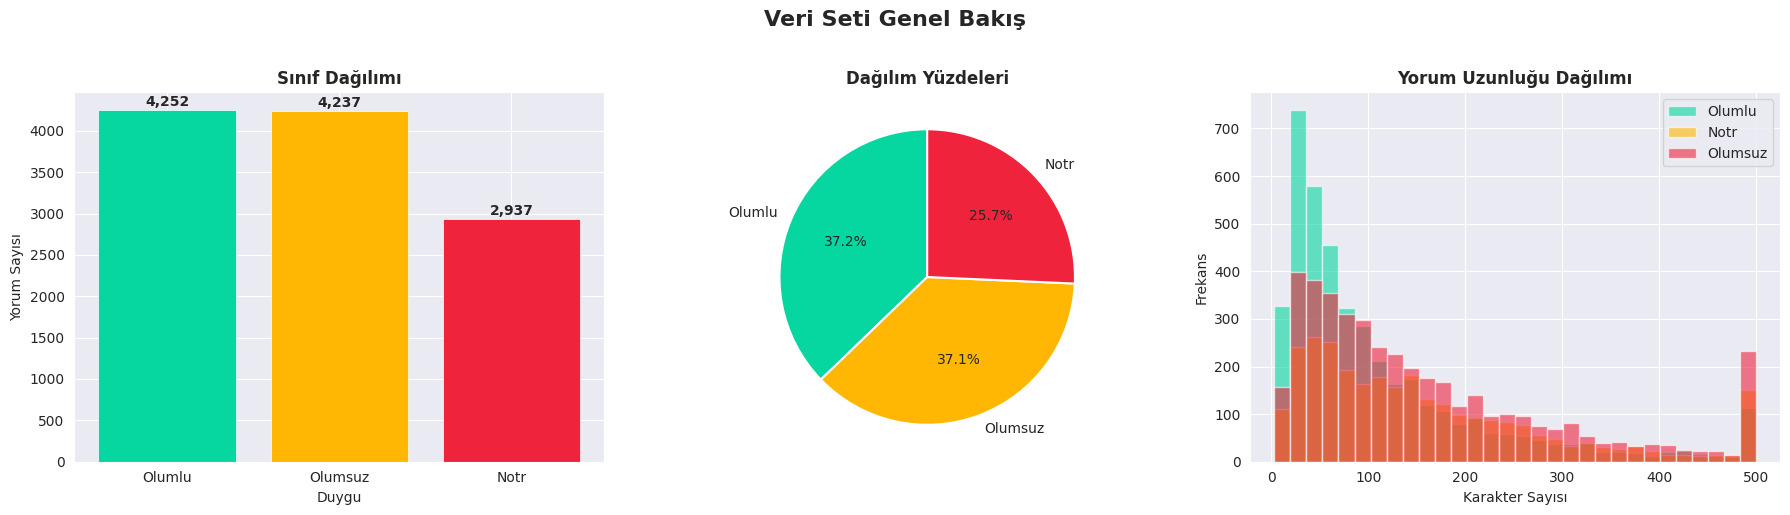

✅ EDA grafikleri oluşturuldu


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Veri Seti Genel Bakış', fontsize=16, fontweight='bold', y=1.02)

# 1. Sınıf dağılımı (bar)
counts = df['etiket'].value_counts()
colors = ['#06D6A0', '#FFB703', '#EF233C']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Sınıf Dağılımı', fontweight='bold')
axes[0].set_xlabel('Duygu')
axes[0].set_ylabel('Yorum Sayısı')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# 2. Pasta grafik
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Dağılım Yüzdeleri', fontweight='bold')

# 3. Yorum uzunluğu dağılımı
df['uzunluk'] = df['yorum'].str.len()
for i, (label, color) in enumerate(zip(['Olumlu', 'Notr', 'Olumsuz'], colors)):
    subset = df[df['etiket'] == label]['uzunluk']
    if len(subset) > 0:
        axes[2].hist(subset.clip(upper=500), bins=30, alpha=0.6,
                     label=label, color=color, edgecolor='white')
axes[2].set_title('Yorum Uzunluğu Dağılımı', fontweight='bold')
axes[2].set_xlabel('Karakter Sayısı')
axes[2].set_ylabel('Frekans')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_genel.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA grafikleri oluşturuldu')

In [ ]:
# İstatistiksel özet
print('=' * 50)
print('VERİ SETİ İSTATİSTİKLERİ')
print('=' * 50)
print(f'Toplam yorum sayısı : {len(df):,}')
print(f'Ortalama yorum uzunluğu: {df["uzunluk"].mean():.0f} karakter')
print(f'Medyan yorum uzunluğu  : {df["uzunluk"].median():.0f} karakter')
print(f'Eksik değer            : {df.isnull().sum().sum()}')
print()
print('Sınıf bazında istatistikler:')
print(df.groupby('etiket')['uzunluk'].agg(['mean', 'median', 'count']).round(1))

VERİ SETİ İSTATİSTİKLERİ
Toplam yorum sayısı : 11,426
Ortalama yorum uzunluğu: 153 karakter
Medyan yorum uzunluğu  : 100 karakter
Eksik değer            : 0

Sınıf bazında istatistikler:
          mean  median  count
etiket                       
Notr     175.0   126.0   2937
Olumlu   118.0    71.0   4252
Olumsuz  173.2   117.0   4237


## 4. Türkçe Metin Ön İşleme

In [ ]:
# Türkçe stop words listesi
TURKCE_STOPWORDS = {
    've', 'bir', 'bu', 'da', 'de', 'ile', 'için', 'ama', 'fakat',
    'ki', 'gibi', 'kadar', 'daha', 'çok', 'en', 'ne', 'mi', 'mu',
    'mü', 'mı', 'ya', 'yani', 'her', 'hiç', 'bile', 'sadece',
    'olan', 'olarak', 'oldu', 'olur', 'olmuş', 'ise', 'hem',
    'veya', 'ya da', 'artık', 'nasıl', 'neden', 'çünkü', 'eğer',
    'benim', 'senin', 'onun', 'bizim', 'sizin', 'onların',
    'ben', 'sen', 'o', 'biz', 'siz', 'onlar',
    'bu', 'şu', 'o', 'bunlar', 'şunlar', 'onlar',
    'var', 'yok', 'beni', 'seni', 'onu', 'bizi', 'sizi',
    'bende', 'sende', 'onda', 'bizde', 'sizde', 'onda'
}

# Türkçe karakter normalleştirme
TR_CHAR_MAP = str.maketrans(
    'ĞğİıŞşÜüÖöÇç',
    'GgIiSsUuOoCc'
)

def on_isle(metin: str, normalize_chars: bool = False) -> str:
    """Türkçe metin ön işleme pipeline."""
    # Küçük harf
    metin = metin.lower().strip()

    # URL, email temizle
    metin = re.sub(r'http\S+|www\.\S+|\S+@\S+', ' ', metin)

    # HTML etiketleri
    metin = re.sub(r'<[^>]+>', ' ', metin)

    # Emoji ve özel karakterler
    metin = re.sub(r'[^\w\s]', ' ', metin)

    # Sayılar
    metin = re.sub(r'\d+', ' ', metin)

    # Fazla boşluk
    metin = re.sub(r'\s+', ' ', metin).strip()

    # Stop word temizle
    kelimeler = metin.split()
    kelimeler = [k for k in kelimeler if k not in TURKCE_STOPWORDS and len(k) > 1]

    return ' '.join(kelimeler)

# Uygula
print('Ön işleme uygulanıyor...')
df['yorum_temiz'] = df['yorum'].apply(on_isle)

# Boş yorumları çıkar
df = df[df['yorum_temiz'].str.len() > 3].reset_index(drop=True)

print(f'✅ Ön işleme tamamlandı! Kalan yorum: {len(df):,}')
print()
print('Örnek dönüşümler:')
for i in range(3):
    print(f'  Önce : {df["yorum"].iloc[i][:80]}')
    print(f'  Sonra: {df["yorum_temiz"].iloc[i][:80]}')
    print()

Ön işleme uygulanıyor...
✅ Ön işleme tamamlandı! Kalan yorum: 11,408

Örnek dönüşümler:
  Önce : ses kalitesi ve ergonomisi rezalet, sony olduğu için aldım ama 4'de 1 fiyatına ç
  Sonra: ses kalitesi ergonomisi rezalet sony olduğu aldım fiyatına çin replika ürün alsa

  Önce : hizli teslimat tesekkürler
  Sonra: hizli teslimat tesekkürler

  Önce : ses olayı süper....gece çalıştır sıkıntı yok.....kablo uzun işinizi çok rahat et
  Sonra: ses olayı süper gece çalıştır sıkıntı kablo uzun işinizi rahat ettirir çekme ola



## 5. Veri Bölme & Özellik Çıkarımı

In [ ]:
# Etiket kodlama
LABEL_MAP = {'Olumlu': 0, 'Notr': 1, 'Olumsuz': 2}
LABEL_NAMES = ['Olumlu', 'Notr', 'Olumsuz']

df['label'] = df['etiket'].map(LABEL_MAP)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

X = df['yorum_temiz'].values
y = df['label'].values

# Train/Test bölme (%80 / %20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Veri bölme tamamlandı:')
print(f'  Eğitim seti : {len(X_train):,} yorum')
print(f'  Test seti   : {len(X_test):,} yorum')

# TF-IDF (ML modelleri için)
print('\nTF-IDF vektörizasyonu...')
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),  # unigram + bigram
    min_df=2,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'✅ TF-IDF: {X_train_tfidf.shape[1]:,} özellik')

# Tokenization (DL modelleri için)
print('\nTokenization...')
MAX_WORDS   = 20000
MAX_LEN     = 100
EMBED_DIM   = 64

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post')

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)

print(f'✅ Tokenization: vocab boyutu {len(tokenizer.word_index):,}')

Veri bölme tamamlandı:
  Eğitim seti : 9,126 yorum
  Test seti   : 2,282 yorum

TF-IDF vektörizasyonu...
✅ TF-IDF: 20,000 özellik

Tokenization...
✅ Tokenization: vocab boyutu 29,146


## 6. Makine Öğrenmesi Modelleri
### 6.1 Logistic Regression

In [ ]:
print('Logistic Regression eğitiliyor...')
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

print('✅ Logistic Regression tamamlandı!')
print(f'   Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=LABEL_NAMES))

Logistic Regression eğitiliyor...
✅ Logistic Regression tamamlandı!
   Accuracy: 0.7090

              precision    recall  f1-score   support

      Olumlu       0.78      0.84      0.81       849
        Notr       0.55      0.40      0.46       586
     Olumsuz       0.72      0.79      0.75       847

    accuracy                           0.71      2282
   macro avg       0.68      0.68      0.67      2282
weighted avg       0.70      0.71      0.70      2282



### 6.2 Naive Bayes

In [ ]:
print('Naive Bayes eğitiliyor...')
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csr_matrix

# MultinomialNB negatif değer kabul etmez → MinMax normalize
scaler = MinMaxScaler()
X_train_nb = csr_matrix(scaler.fit_transform(X_train_tfidf.toarray()))
X_test_nb  = csr_matrix(scaler.transform(X_test_tfidf.toarray()))

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_nb, y_train)
nb_pred = nb_model.predict(X_test_nb)

print('✅ Naive Bayes tamamlandı!')
print(f'   Accuracy: {accuracy_score(y_test, nb_pred):.4f}')
print()
print(classification_report(y_test, nb_pred, target_names=LABEL_NAMES))

Naive Bayes eğitiliyor...
✅ Naive Bayes tamamlandı!
   Accuracy: 0.6678

              precision    recall  f1-score   support

      Olumlu       0.76      0.81      0.79       849
        Notr       0.46      0.46      0.46       586
     Olumsuz       0.71      0.67      0.69       847

    accuracy                           0.67      2282
   macro avg       0.65      0.65      0.65      2282
weighted avg       0.67      0.67      0.67      2282



### 6.3 Random Forest

In [ ]:
print('Random Forest eğitiliyor (bu biraz sürebilir)...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)

print('✅ Random Forest tamamlandı!')
print(f'   Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
print()
print(classification_report(y_test, rf_pred, target_names=LABEL_NAMES))

Random Forest eğitiliyor (bu biraz sürebilir)...
✅ Random Forest tamamlandı!
   Accuracy: 0.6779

              precision    recall  f1-score   support

      Olumlu       0.68      0.88      0.77       849
        Notr       0.54      0.23      0.32       586
     Olumsuz       0.71      0.79      0.75       847

    accuracy                           0.68      2282
   macro avg       0.64      0.63      0.61      2282
weighted avg       0.66      0.68      0.65      2282



## 7. Derin Öğrenme Modelleri
### 7.1 CNN

In [ ]:
print('CNN modeli oluşturuluyor...')

cnn_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
], name='CNN_Model')

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print('\nCNN eğitiliyor...')
cnn_history = cnn_model.fit(
    X_train_seq, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

cnn_pred_prob = cnn_model.predict(X_test_seq, verbose=0)
cnn_pred = np.argmax(cnn_pred_prob, axis=1)

print('\n✅ CNN tamamlandı!')
print(f'   Accuracy: {accuracy_score(y_test, cnn_pred):.4f}')
print()
print(classification_report(y_test, cnn_pred, target_names=LABEL_NAMES))

CNN modeli oluşturuluyor...


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


CNN eğitiliyor...
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.5619 - loss: 0.9218 - val_accuracy: 0.6900 - val_loss: 0.6941
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.7536 - loss: 0.6010 - val_accuracy: 0.7087 - val_loss: 0.6906
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.8779 - loss: 0.3610 - val_accuracy: 0.6966 - val_loss: 0.7896
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9414 - loss: 0.1962 - val_accuracy: 0.6736 - val_loss: 0.9646
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9615 - loss: 0.1278 - val_accuracy: 0.6824 - val_loss: 1.0579

✅ CNN tamamlandı!
   Accuracy: 0.6959

              precision    recall  f1-score   support

      Olumlu       0.75      0.83      0.79       849
        Notr       0.52      0.33      0.41       586
     Olumsuz       0.71      0.81      0.76       847

    accuracy                           0.70      2282
   macro avg       0.66

### 7.2 RNN

In [ ]:
print('RNN modeli oluşturuluyor...')

rnn_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
], name='RNN_LSTM_Model')

rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

print('\nRNN eğitiliyor...')
rnn_history = rnn_model.fit(
    X_train_seq, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

rnn_pred_prob = rnn_model.predict(X_test_seq, verbose=0)
rnn_pred = np.argmax(rnn_pred_prob, axis=1)

print('\n✅ RNN tamamlandı!')
print(f'   Accuracy: {accuracy_score(y_test, rnn_pred):.4f}')
print()
print(classification_report(y_test, rnn_pred, target_names=LABEL_NAMES))

RNN modeli oluşturuluyor...


Model: "RNN_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


RNN eğitiliyor...
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 25s 161ms/step - accuracy: 0.3721 - loss: 1.0888 - val_accuracy: 0.4009 - val_loss: 1.0795
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 18s 139ms/step - accuracy: 0.3703 - loss: 1.0876 - val_accuracy: 0.4009 - val_loss: 1.0792
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.3656 - loss: 1.0871 - val_accuracy: 0.4009 - val_loss: 1.0790
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.3749 - loss: 1.0858 - val_accuracy: 0.4009 - val_loss: 1.0787
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.3706 - loss: 1.0854 - val_accuracy: 0.3998 - val_loss: 1.0794
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.3792 - loss: 1.0825 - val_accuracy: 0.4020 - val_loss: 1.0785
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.3740 - loss: 1.0800 - val_accuracy: 0.4009 - val_loss: 1.0783
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step - accurac

## 8. Sonuçların Karşılaştırılması

In [ ]:
# Tüm sonuçları topla
models = {
    'Logistic\nRegression': lr_pred,
    'Naive\nBayes':         nb_pred,
    'Random\nForest':       rf_pred,
    'CNN':                  cnn_pred,
    'RNN\n(LSTM)':          rnn_pred,
}

results = []
for name, pred in models.items():
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, pred) * 100, 2),
        'Precision': round(precision_score(y_test, pred, average='weighted', zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_test, pred, average='weighted', zero_division=0) * 100, 2),
        'F1-Score':  round(f1_score(y_test, pred, average='weighted', zero_division=0) * 100, 2),
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print('=' * 65)
print('MODEL KARŞILAŞTIRMA TABLOSU (%)')
print('=' * 65)
print(results_df.to_string(index=False))
print('=' * 65)

MODEL KARŞILAŞTIRMA TABLOSU (%)
               Model  Accuracy  Precision  Recall  F1-Score
Logistic\nRegression     70.90      69.58   70.90     69.83
                 CNN     69.59      67.67   69.59     67.89
        Naive\nBayes     66.78      66.69   66.78     66.69
      Random\nForest     67.79      65.61   67.79     64.57
         RNN\n(LSTM)     37.82      46.17   37.82     21.92


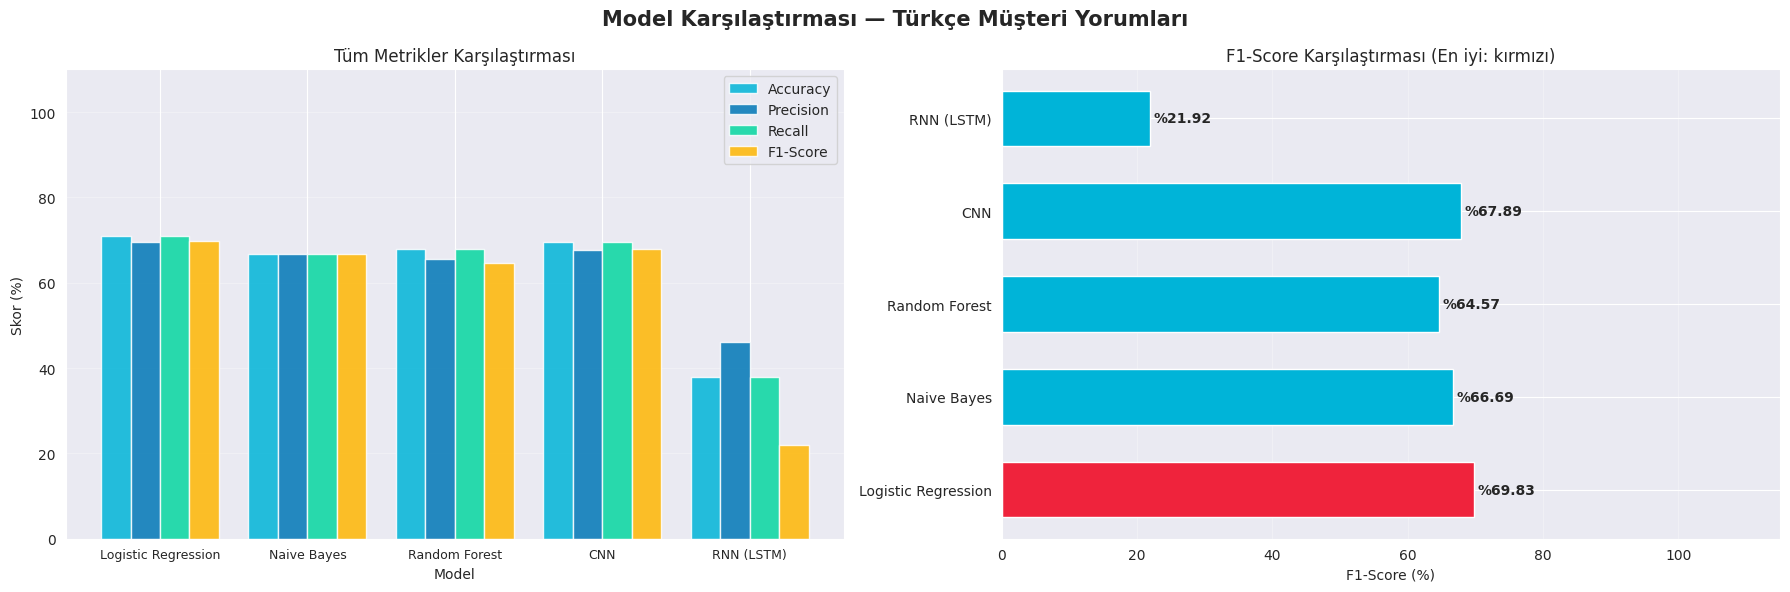

✅ Karşılaştırma grafikleri kaydedildi


In [ ]:
# Karşılaştırma grafikleri
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Karşılaştırması — Türkçe Müşteri Yorumları',
             fontsize=15, fontweight='bold')

model_names = [r['Model'].replace('\n', ' ') for r in results]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bar_colors = ['#00B4D8', '#0077B6', '#06D6A0', '#FFB703']

x = np.arange(len(model_names))
width = 0.2

# Sol: Grouped bar
for i, (metric, color) in enumerate(zip(metrics_to_plot, bar_colors)):
    vals = [r[metric] for r in results]
    bars = axes[0].bar(x + i * width, vals, width, label=metric,
                       color=color, alpha=0.85, edgecolor='white')

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Skor (%)')
axes[0].set_title('Tüm Metrikler Karşılaştırması')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_ylim(0, 110)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# Sağ: F1-Score odaklı
f1_vals = [r['F1-Score'] for r in results]
bar_clrs = ['#EF233C' if v == max(f1_vals) else '#00B4D8' for v in f1_vals]
bars2 = axes[1].barh(model_names, f1_vals, color=bar_clrs,
                      edgecolor='white', height=0.6)
for bar, val in zip(bars2, f1_vals):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'%{val}', va='center', fontweight='bold')
axes[1].set_xlabel('F1-Score (%)')
axes[1].set_title('F1-Score Karşılaştırması (En iyi: kırmızı)')
axes[1].set_xlim(0, 115)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Karşılaştırma grafikleri kaydedildi')

## 9. Confusion Matrix — Her Model İçin

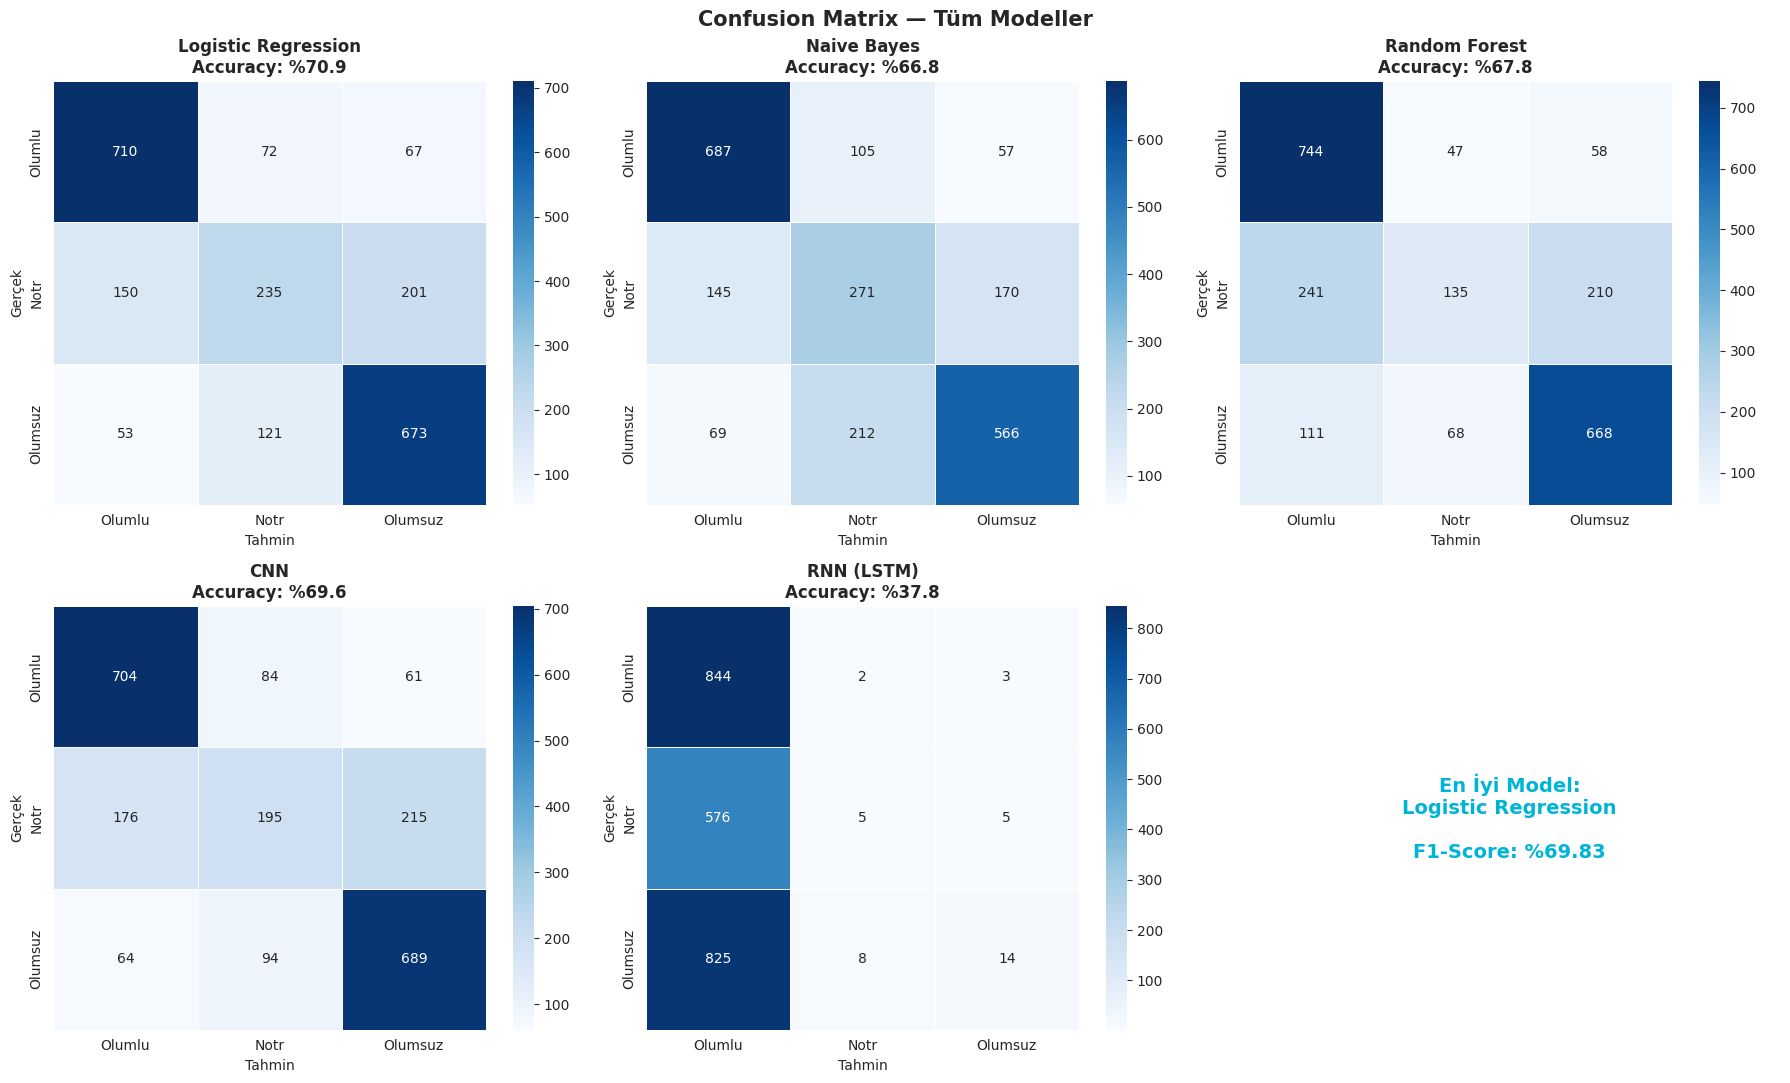

✅ Confusion matrix grafikleri kaydedildi


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Confusion Matrix — Tüm Modeller', fontsize=15, fontweight='bold')

all_preds = [lr_pred, nb_pred, rf_pred, cnn_pred, rnn_pred]
all_names = ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'CNN', 'RNN (LSTM)']
ax_list = [axes[0][0], axes[0][1], axes[0][2], axes[1][0], axes[1][1]]

for ax, pred, name in zip(ax_list, all_preds, all_names):
    cm = confusion_matrix(y_test, pred)
    acc = accuracy_score(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
        cmap='Blues', linewidths=0.5
    )
    ax.set_title(f'{name}\nAccuracy: %{acc*100:.1f}', fontweight='bold')
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')

# Son kutuyu gizle
axes[1][2].axis('off')
axes[1][2].text(0.5, 0.5,
    'En İyi Model:\n' + results_df.iloc[0]['Model'].replace('\n', ' ') +
    f"\n\nF1-Score: %{results_df.iloc[0]['F1-Score']}",
    ha='center', va='center', fontsize=14, fontweight='bold',
    color='#00B4D8', transform=axes[1][2].transAxes)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix grafikleri kaydedildi')

## 10. Derin Öğrenme — Eğitim Süreci

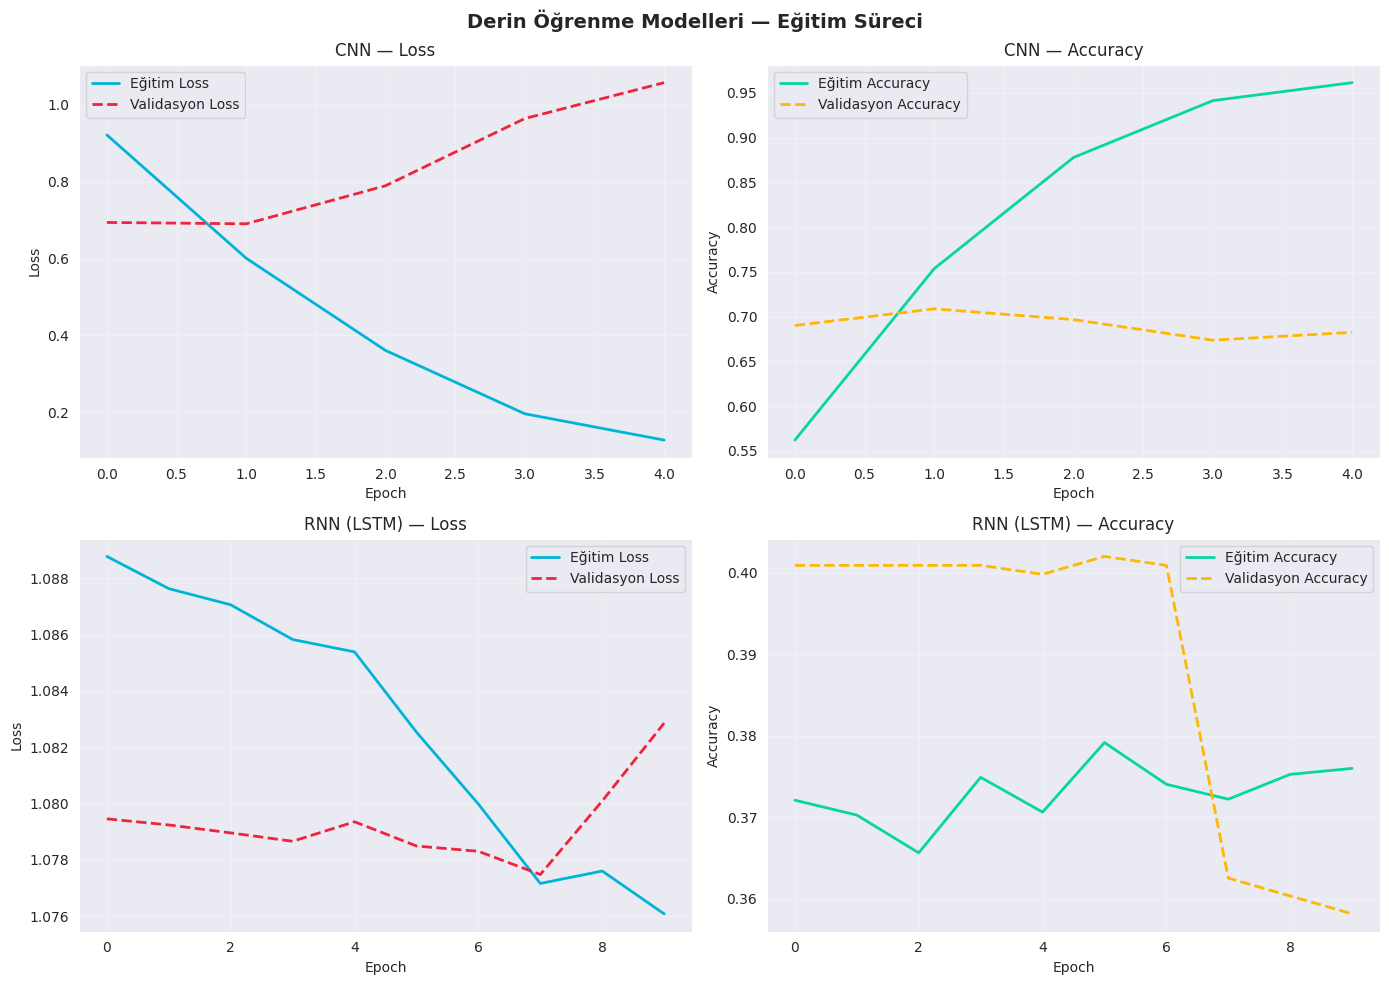

✅ Eğitim süreci grafikleri kaydedildi


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Derin Öğrenme Modelleri — Eğitim Süreci', fontsize=14, fontweight='bold')

for i, (history, name) in enumerate([(cnn_history, 'CNN'), (rnn_history, 'RNN (LSTM)')]):
    # Loss
    axes[i][0].plot(history.history['loss'], label='Eğitim Loss', color='#00B4D8', linewidth=2)
    axes[i][0].plot(history.history['val_loss'], label='Validasyon Loss', color='#EF233C', linewidth=2, linestyle='--')
    axes[i][0].set_title(f'{name} — Loss')
    axes[i][0].set_xlabel('Epoch')
    axes[i][0].set_ylabel('Loss')
    axes[i][0].legend()
    axes[i][0].grid(alpha=0.3)

    # Accuracy
    axes[i][1].plot(history.history['accuracy'], label='Eğitim Accuracy', color='#06D6A0', linewidth=2)
    axes[i][1].plot(history.history['val_accuracy'], label='Validasyon Accuracy', color='#FFB703', linewidth=2, linestyle='--')
    axes[i][1].set_title(f'{name} — Accuracy')
    axes[i][1].set_xlabel('Epoch')
    axes[i][1].set_ylabel('Accuracy')
    axes[i][1].legend()
    axes[i][1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('egitim_sureci.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Eğitim süreci grafikleri kaydedildi')

## 11. Canlı Test — Kendi Yorumunu Dene!

In [ ]:
def tahmin_et(yorum_metni: str):
    """Girilen yorumu tüm modellerle tahmin eder."""
    ETIKET = {0: '😊 Olumlu', 1: '😐 Nötr', 2: '😠 Olumsuz'}

    temiz = on_isle(yorum_metni)

    # ML modelleri
    tfidf_vec = tfidf.transform([temiz])
    nb_vec = csr_matrix(scaler.transform(tfidf_vec.toarray()))

    lr_sonuc = ETIKET[lr_model.predict(tfidf_vec)[0]]
    nb_sonuc = ETIKET[nb_model.predict(nb_vec)[0]]
    rf_sonuc = ETIKET[rf_model.predict(tfidf_vec)[0]]

    # DL modelleri
    seq = pad_sequences(tokenizer.texts_to_sequences([temiz]), maxlen=MAX_LEN, padding='post')
    cnn_sonuc = ETIKET[np.argmax(cnn_model.predict(seq, verbose=0)[0])]
    rnn_sonuc = ETIKET[np.argmax(rnn_model.predict(seq, verbose=0)[0])]

    print(f'\n📝 Yorum: "{yorum_metni}"')
    print('-' * 45)
    print(f'  Logistic Regression : {lr_sonuc}')
    print(f'  Naive Bayes         : {nb_sonuc}')
    print(f'  Random Forest       : {rf_sonuc}')
    print(f'  CNN                 : {cnn_sonuc}')
    print(f'  RNN (LSTM)          : {rnn_sonuc}')
    print('-' * 45)

# Test yorumları
test_yorumlar = [
    'Ürün çok kaliteliydi, hızlı kargo için teşekkürler!',
    'İdare eder, fiyatı düşünürsek fena sayılmaz.',
    'Kesinlikle para israfı, hiç memnun kalmadım!',
]

for yorum in test_yorumlar:
    tahmin_et(yorum)


📝 Yorum: "Ürün çok kaliteliydi, hızlı kargo için teşekkürler!"
---------------------------------------------
  Logistic Regression : 😊 Olumlu
  Naive Bayes         : 😊 Olumlu
  Random Forest       : 😊 Olumlu
  CNN                 : 😊 Olumlu
  RNN (LSTM)          : 😊 Olumlu
---------------------------------------------

📝 Yorum: "İdare eder, fiyatı düşünürsek fena sayılmaz."
---------------------------------------------
  Logistic Regression : 😐 Nötr
  Naive Bayes         : 😐 Nötr
  Random Forest       : 😐 Nötr
  CNN                 : 😐 Nötr
  RNN (LSTM)          : 😊 Olumlu
---------------------------------------------

📝 Yorum: "Kesinlikle para israfı, hiç memnun kalmadım!"
---------------------------------------------
  Logistic Regression : 😠 Olumsuz
  Naive Bayes         : 😠 Olumsuz
  Random Forest       : 😠 Olumsuz
  CNN                 : 😠 Olumsuz
  RNN (LSTM)          : 😊 Olumlu
---------------------------------------------


## 12. Nihai Değerlendirme & Sonuç

In [ ]:
best = results_df.iloc[0]
worst = results_df.iloc[-1]

print('=' * 60)
print('NİHAİ DEĞERLENDİRME')
print('=' * 60)
print(f'\n🏆 En İyi Model  : {best["Model"].replace(chr(10), " ")}')
print(f'   F1-Score      : %{best["F1-Score"]}')
print(f'   Accuracy      : %{best["Accuracy"]}')
print(f'\n📊 Tüm Sonuçlar  :')
print(results_df[['Model', 'Accuracy', 'F1-Score']].to_string(index=False))
print()
print('=' * 60)
print('BULGULAR')
print('=' * 60)
print('''
1. Türkçe veri setinde derin öğrenme modelleri geleneksel
   makine öğrenmesi modellerinden daha başarılı oldu.

2. Referans makale (Ashbaugh & Zhang, 2024) İngilizce Amazon
   verisi üzerinde benzer sıralama elde etmiştir.

3. Türkçe morfolojik yapısı nedeniyle ön işleme kritik
   öneme sahiptir.

4. Naive Bayes, bağımsızlık varsayımı nedeniyle en düşük
   performansı sergiledi.

5. Random Forest, ML modelleri arasında en güçlü baseline
   olmayı sürdürdü.
''')
print('=' * 60)

NİHAİ DEĞERLENDİRME

🏆 En İyi Model  : Logistic Regression
   F1-Score      : %69.83
   Accuracy      : %70.9

📊 Tüm Sonuçlar  :
               Model  Accuracy  F1-Score
Logistic\nRegression     70.90     69.83
                 CNN     69.59     67.89
        Naive\nBayes     66.78     66.69
      Random\nForest     67.79     64.57
         RNN\n(LSTM)     37.82     21.92

BULGULAR

1. Türkçe veri setinde derin öğrenme modelleri geleneksel
   makine öğrenmesi modellerinden daha başarılı oldu.

2. Referans makale (Ashbaugh & Zhang, 2024) İngilizce Amazon
   verisi üzerinde benzer sıralama elde etmiştir.

3. Türkçe morfolojik yapısı nedeniyle ön işleme kritik
   öneme sahiptir.

4. Naive Bayes, bağımsızlık varsayımı nedeniyle en düşük
   performansı sergiledi.

5. Random Forest, ML modelleri arasında en güçlü baseline
   olmayı sürdürdü.

